## Workspace setup

In [ ]:
from datetime import datetime  
import uproot
from functools import partial
import numpy as np
import tensorflow as tf
import tensorflow_datasets as tfds

import importlib

# Notebooks run from VSCode use home directory as a base path
# while notebooks run from JupyterLab use the current directory as a base path
import sys
sys.path.append("/home/akalinow/scratch/ELITPC/TPCReco/PythonAnalysis/python/")

# Change directory to the working directory
import os
os.chdir('/scratch_hdd/akalinow/ELITPC/PythonAnalysis/')

## Training dataset preparation

In [ ]:
import io_functions as io
importlib.reload(io)

import plotting_functions as plf
importlib.reload(plf)

batchSize = 32
dataset = tf.data.Dataset.load('SimEvent_Track3D_TwoProng_gun_MC', compression="GZIP")
dataset = dataset.batch(batchSize, drop_remainder=True)
dataset = dataset.map(lambda x,y: (tf.reshape(x, (-1,)+io.projections.shape), tf.reshape(y, (-1,9))))
dataset = dataset.cache().prefetch(tf.data.AUTOTUNE)
tfds.benchmark(dataset,batch_size=batchSize)

## Model definition

In [ ]:
model = tf.keras.Sequential([
  tf.keras.layers.Input(shape=(256,512,3), name="input_image", dtype=tf.float32),
  tf.keras.layers.Normalization(name='norm'),
  #tf.keras.layers.Resizing(height=128, width=128), 
  tf.keras.layers.Conv2D(16, 10, padding='same', activation='relu', 
                         data_format="channels_last"),
  tf.keras.layers.MaxPooling2D(),
  tf.keras.layers.Conv2D(32, 2, padding='same', activation='relu', 
                         data_format="channels_last"),
  tf.keras.layers.MaxPooling2D(),
  tf.keras.layers.Conv2D(32, 2, padding='same', activation='relu', 
                         data_format="channels_last"),
  tf.keras.layers.MaxPooling2D(),
  tf.keras.layers.Flatten(),
  tf.keras.layers.Dense(16, activation='relu',
                        kernel_initializer=tf.keras.initializers.HeNormal(),
                        bias_initializer=tf.keras.initializers.RandomUniform(minval=-1, maxval=1)),
  tf.keras.layers.Dense(16, activation='relu',
                        kernel_initializer=tf.keras.initializers.HeNormal(),
                        bias_initializer=tf.keras.initializers.RandomUniform(minval=-1, maxval=1)),
  tf.keras.layers.Dense(16, activation='relu',
                        kernel_initializer=tf.keras.initializers.HeNormal(),
                        bias_initializer=tf.keras.initializers.RandomUniform(minval=-1, maxval=1)),
  tf.keras.layers.Dense(9, activation="linear",),
  #tf.keras.layers.Rescaling(scale=512)
])

initial_learning_rate = 0.01
lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(initial_learning_rate,
                decay_steps=370,
                decay_rate=0.98,
                staircase=False)

optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule) 
model.compile(optimizer = optimizer, 
              loss = 'mse', 
              metrics=['mse']) 

model.summary()


Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ norm (Normalization)            │ (None, 256, 512, 3)    │             7 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_36 (Conv2D)              │ (None, 256, 512, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_36 (MaxPooling2D) │ (None, 128, 256, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_37 (Conv2D)              │ (None, 128, 256, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_37 (MaxPooling2D) │ (None, 64, 128, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_38 (Conv2D)              │ (None, 64, 128, 32)    │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_38 (MaxPooling2D) │ (None, 32, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_12 (Flatten)            │ (None, 65536)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_44 (Dense)                │ (None, 16)             │     1,048,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_45 (Dense)                │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_46 (Dense)                │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_47 (Dense)                │ (None, 9)              │           153 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,063,632 (4.06 MB)

 Trainable params: 1,063,625 (4.06 MB)

 Non-trainable params: 7 (32.00 B)

In [69]:
tfds.benchmark(dataset,batch_size=batchSize)
model.evaluate(dataset.take(10))

item = next(iter(dataset.take(1)))
model(item)[0]


************ Summary ************



  0%|          | 0/381 [00:00<?, ?it/s]

Examples/sec (First included) 152281.82 ex/sec (total: 12224 ex, 0.08 sec)
Examples/sec (First only) 2686.18 ex/sec (total: 32 ex, 0.01 sec)
Examples/sec (First excluded) 178351.49 ex/sec (total: 12192 ex, 0.07 sec)


2025-07-04 16:03:48.769037: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - loss: 2281.8892 - mse: 2281.8892


<tf.Tensor: shape=(9,), dtype=float32, numpy=
array([-0.32823953,  0.23574668,  0.15840834, -1.6059712 , -1.8705965 ,
        1.3573315 ,  0.29729965,  1.3132209 ,  1.4567949 ], dtype=float32)>

## Model training

Epoch 1/3
371/371 ━━━━━━━━━━━━━━━━━━━━ 38s 95ms/step - loss: 1048.9210 - mse: 1048.9210 - val_loss: 486.6921 - val_mse: 486.6921
Epoch 2/3
371/371 ━━━━━━━━━━━━━━━━━━━━ 24s 64ms/step - loss: 466.7724 - mse: 466.7724 - val_loss: 331.7747 - val_mse: 331.7747
Epoch 3/3
371/371 ━━━━━━━━━━━━━━━━━━━━ 23s 63ms/step - loss: 349.4851 - mse: 349.4851 - val_loss: 306.4846 - val_mse: 306.4846
Training start. Current Time = 2025_Jul_04_16_05_18
CPU times: user 41.3 s, sys: 4.25 s, total: 45.5 s
Wall time: 1min 25s


<tf.Tensor: shape=(9,), dtype=float32, numpy=
array([ 85.47241  ,  64.91658  ,  88.35824  ,  -1.2157718,   1.6697673,
         1.1278768, -53.93139  , -35.439568 , -55.970345 ], dtype=float32)>

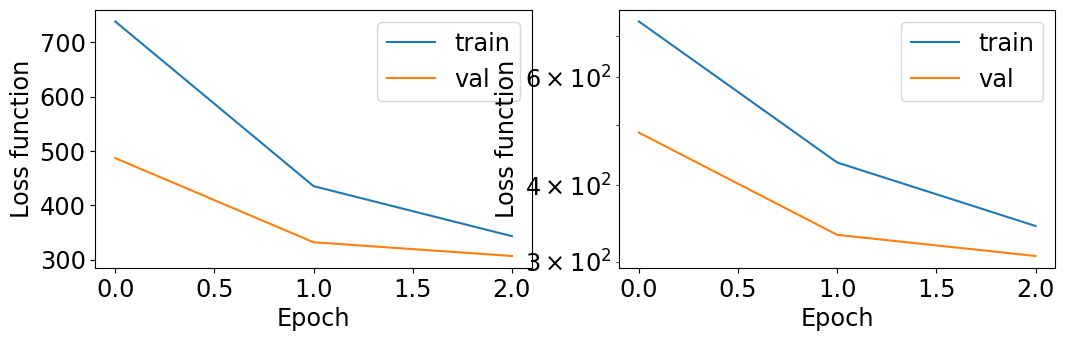

In [70]:
%%time

import plotting_functions as plf
importlib.reload(plf)

log_dir = "logs/fit/" + datetime.now().strftime("%Y%m%d-%H%M%S")
#tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1, profile_batch=(10, 20))
early_stop_callback = tf.keras.callbacks.EarlyStopping(patience=5, verbose=1)
callbacks =  [early_stop_callback]

epochs=3
history = model.fit(dataset.skip(10), 
                    epochs=epochs,
                    verbose = 1,
                    validation_data = dataset.take(10),
                    callbacks=callbacks
                    )
plf.plotTrainHistory(history)

current_time = datetime.now().strftime("%Y_%b_%d_%H_%M_%S")
print("Training start. Current Time =", current_time)

job_dir = f"training/{epochs:04d}_"+current_time+".keras"
model.save(job_dir)

item = next(iter(dataset))
model(item)[0]

## Model performance on training data.

Fill Pandas DataFrame with true and response values.

In [71]:
%%time
import utility_functions as utils
importlib.reload(utils)

#model_path = "./training/2023_Apr_28_16_58_32/"
#model = tf.keras.models.load_model(model_path)

df = utils.getEmptyPandasDataset(utils.columnsXYZ)

for aBatch in dataset: 
    df = utils.fillPandasDataset(aBatch, df, model)     
    
'''
for aBatch in dataset.take(5):
    plf.plotEvent(aBatch, model=model)
'''
df.describe()    

CPU times: user 8.8 s, sys: 305 ms, total: 9.11 s
Wall time: 19.8 s


2025-07-04 16:06:24.562219: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


,xVtx_sim,xAlpha_sim,xCarbon_sim,yVtx_sim,yAlpha_sim,yCarbon_sim,zVtx_sim,zAlpha_sim,zCarbon_sim,xVtx_reco,xAlpha_reco,xCarbon_reco,yVtx_reco,yAlpha_reco,yCarbon_reco,zVtx_reco,zAlpha_reco,zCarbon_reco
count,12192.000000,12192.000000,12192.000000,12192.000000,12192.000000,12192.000000,12192.000000,12192.000000,12192.000000,12192.000000,12192.000000,12192.000000,12192.000000,12192.000000,12192.000000,12192.000000,12192.000000,12192.000000
mean,0.082582,-2.180905,-0.493273,0.039961,-0.196234,0.055905,-31.554533,-31.547850,-31.559736,-0.234646,5.092196,-0.472107,-0.148405,3.680887,1.222639,-34.674801,-34.756214,-34.685661
std,58.080875,75.343628,58.441067,3.208192,47.281696,6.979694,25.772118,32.298996,30.738733,61.000805,69.747841,61.797699,0.799341,1.927378,0.654216,24.633778,30.193285,29.339008
min,-99.972374,-164.977859,-115.032654,-8.536806,-98.750000,-28.792864,-52.944794,-66.150398,-52.946159,-119.958992,-182.948395,-123.894058,-3.299129,-3.336153,-0.702641,-71.937737,-96.612305,-90.998627
25%,-50.544242,-57.758303,-50.626267,-2.496268,-30.337362,-5.051247,-48.730128,-52.934999,-52.946159,-56.260554,-44.548501,-57.272221,-0.755487,2.231001,0.841223,-50.895926,-54.860645,-54.092275
50%,0.504373,-1.873825,-0.140496,0.068588,0.729088,0.020650,-43.994110,-51.448381,-52.396482,1.328757,11.066866,-0.036439,-0.011798,3.341967,1.164911,-45.660467,-46.612362,-49.844780
75%,50.800361,53.605465,50.117560,2.603805,29.848836,5.163560,-22.401044,-17.563098,-17.356832,54.342937,53.695601,54.428945,0.493532,5.065175,1.545657,-25.107626,-21.206695,-21.057141
max,99.986748,164.977814,112.561882,8.137836,98.750000,22.596178,52.566353,65.984474,65.927322,117.875717,191.968231,126.804070,1.733075,11.622413,3.838414,52.943451,85.001907,66.663712


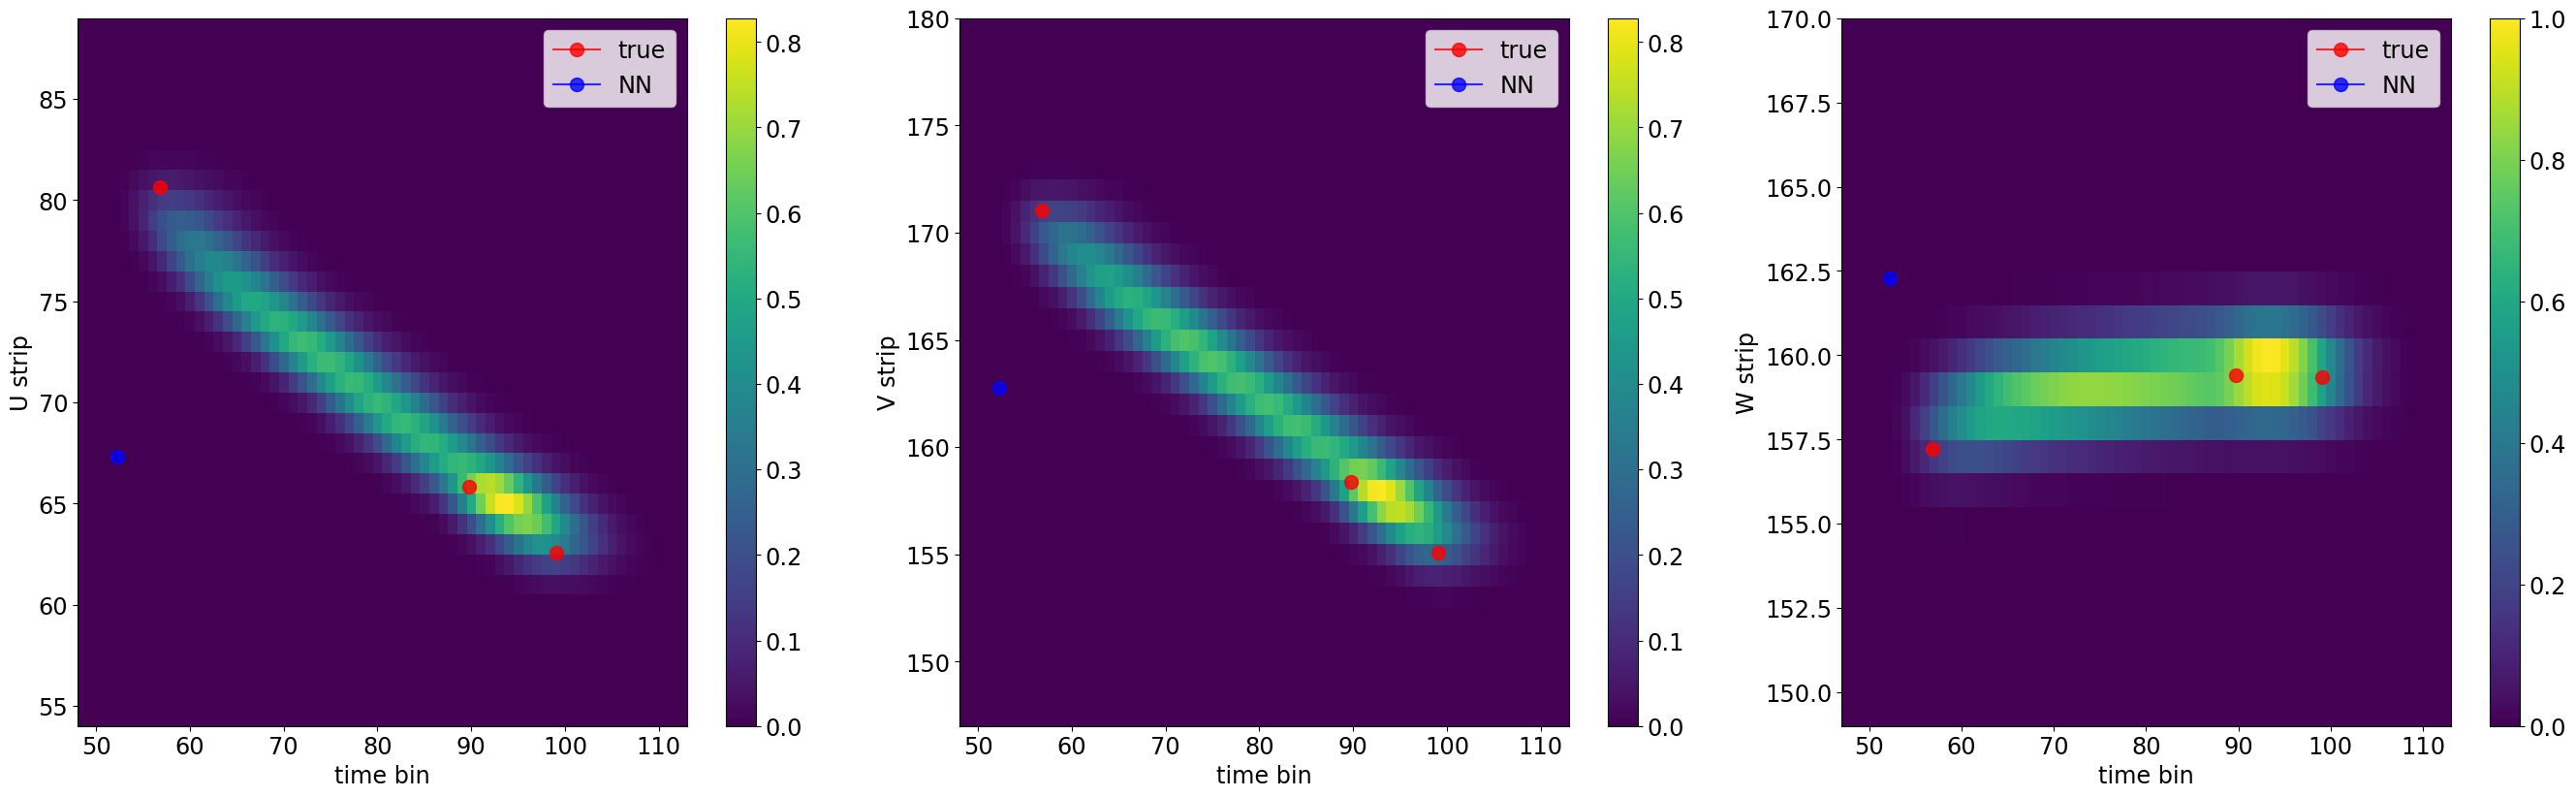

In [76]:
import plotting_functions as plf
importlib.reload(plf)

import utility_functions as utils
importlib.reload(utils)

item = next(iter(dataset))
plf.plotEvent(item, model=model)

### Resolution plots

/home/akalinow/scratch/ELITPC/TPCReco/PythonAnalysis/python/plotting_functions.py:374: RuntimeWarning: divide by zero encountered in divide
  axes[0].hist(RECO_cosAlpha, bins=np.linspace(-1, -0.95, 40), alpha=0.5, label="NN");
/home/akalinow/scratch/ELITPC/TPCReco/PythonAnalysis/python/plotting_functions.py:375: RuntimeWarning: divide by zero encountered in divide
  axes[0].hist(GEN_cosAlpha, bins=np.linspace(-1, -0.95, 40), alpha=0.8, label="true");
/usr/local/lib/python3.11/dist-packages/numpy/core/_methods.py:173: RuntimeWarning: invalid value encountered in subtract
  x = asanyarray(arr - arrmean)
/home/akalinow/scratch/ELITPC/TPCReco/PythonAnalysis/python/plotting_functions.py:378: RuntimeWarning: divide by zero encountered in divide
  


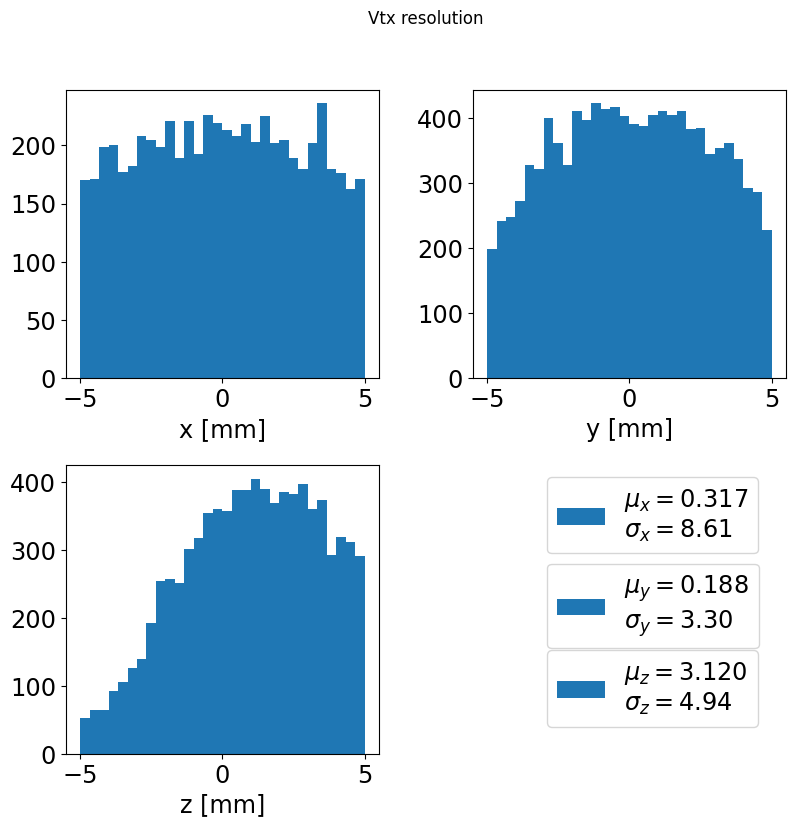

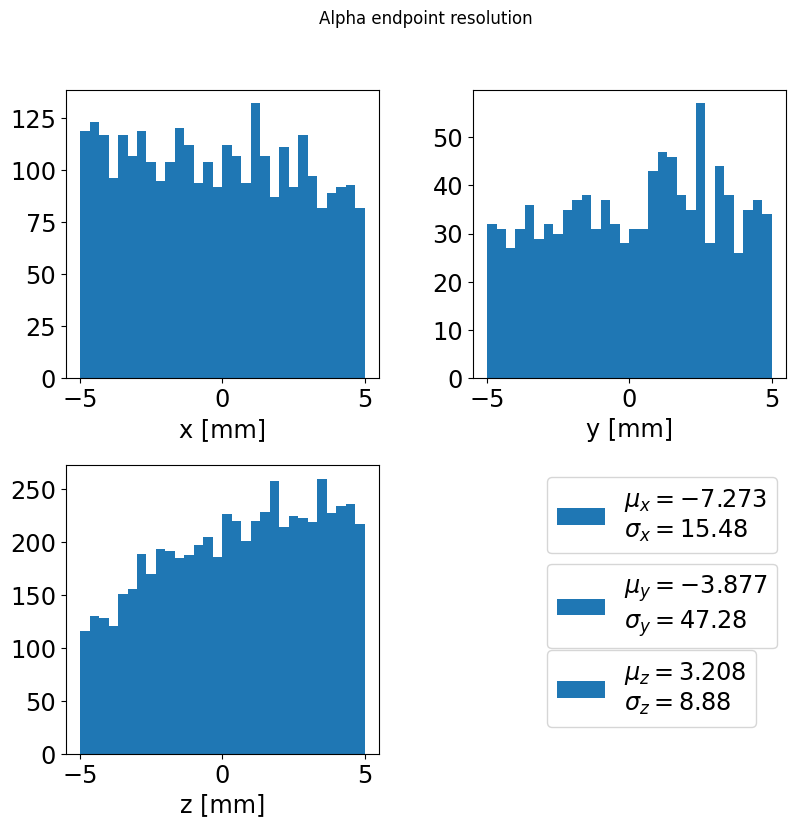

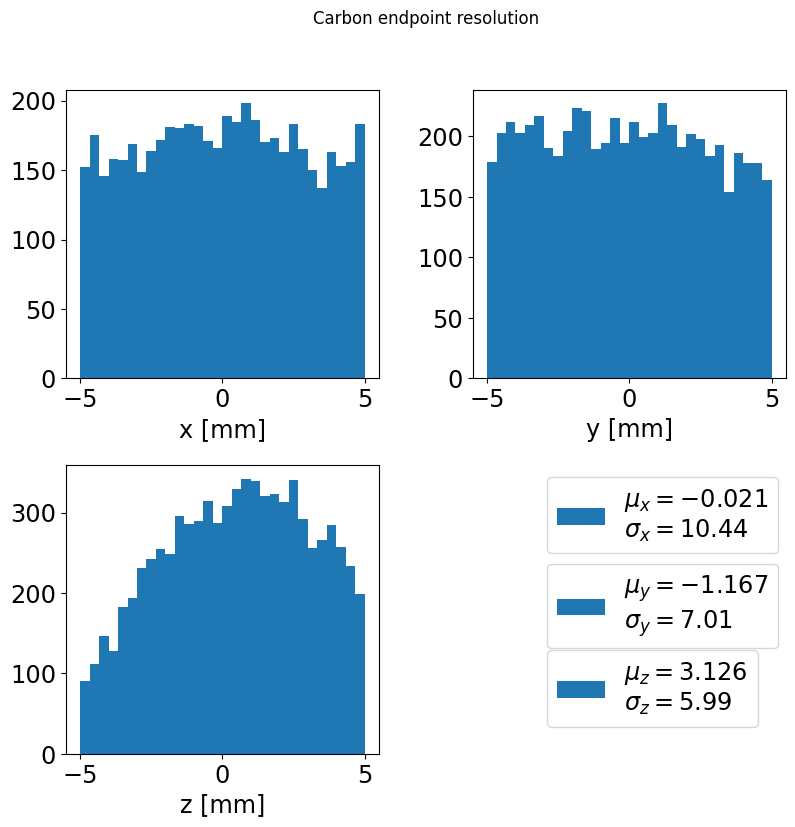

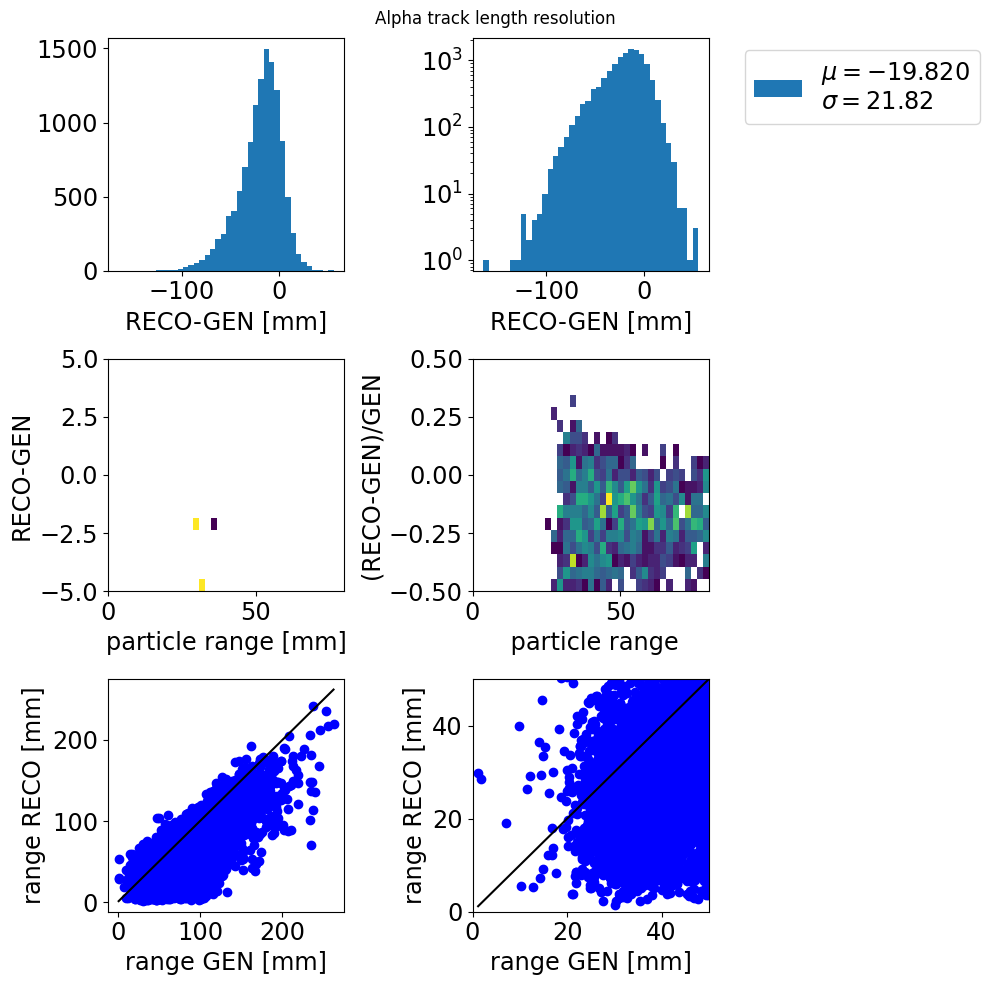

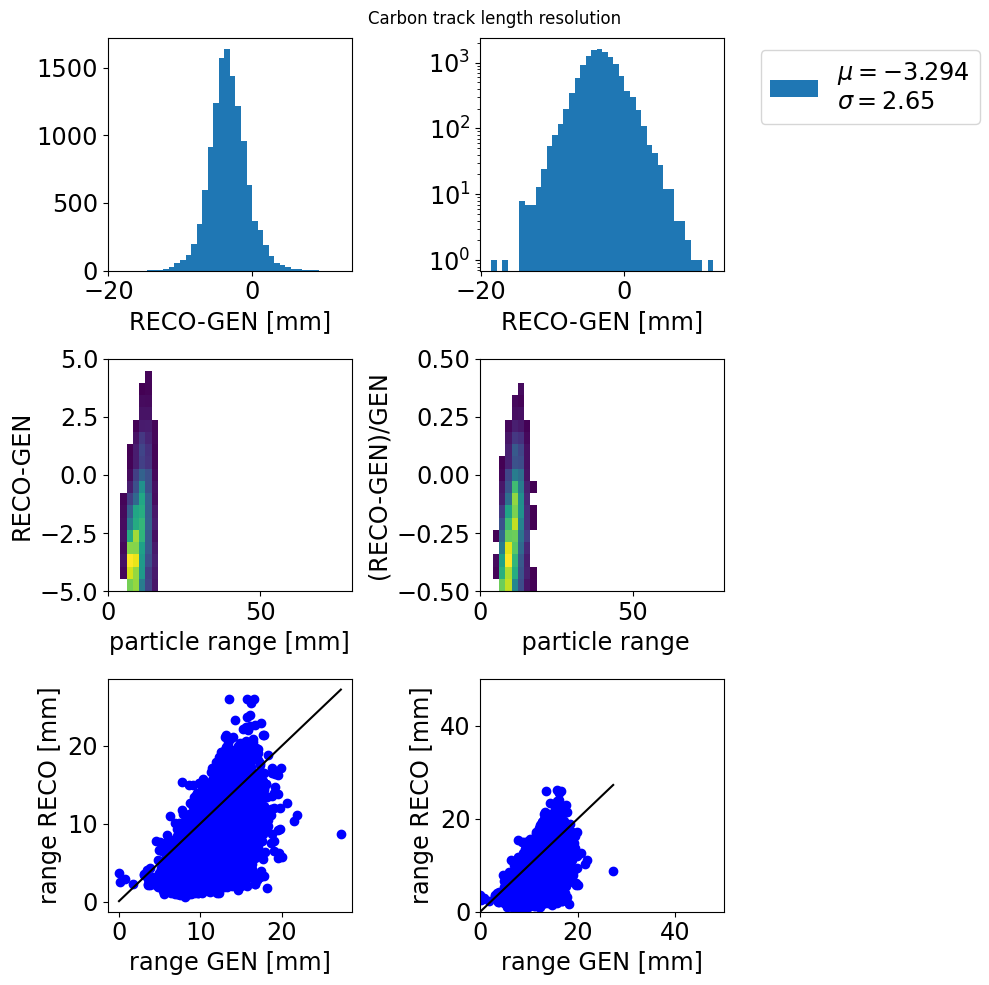

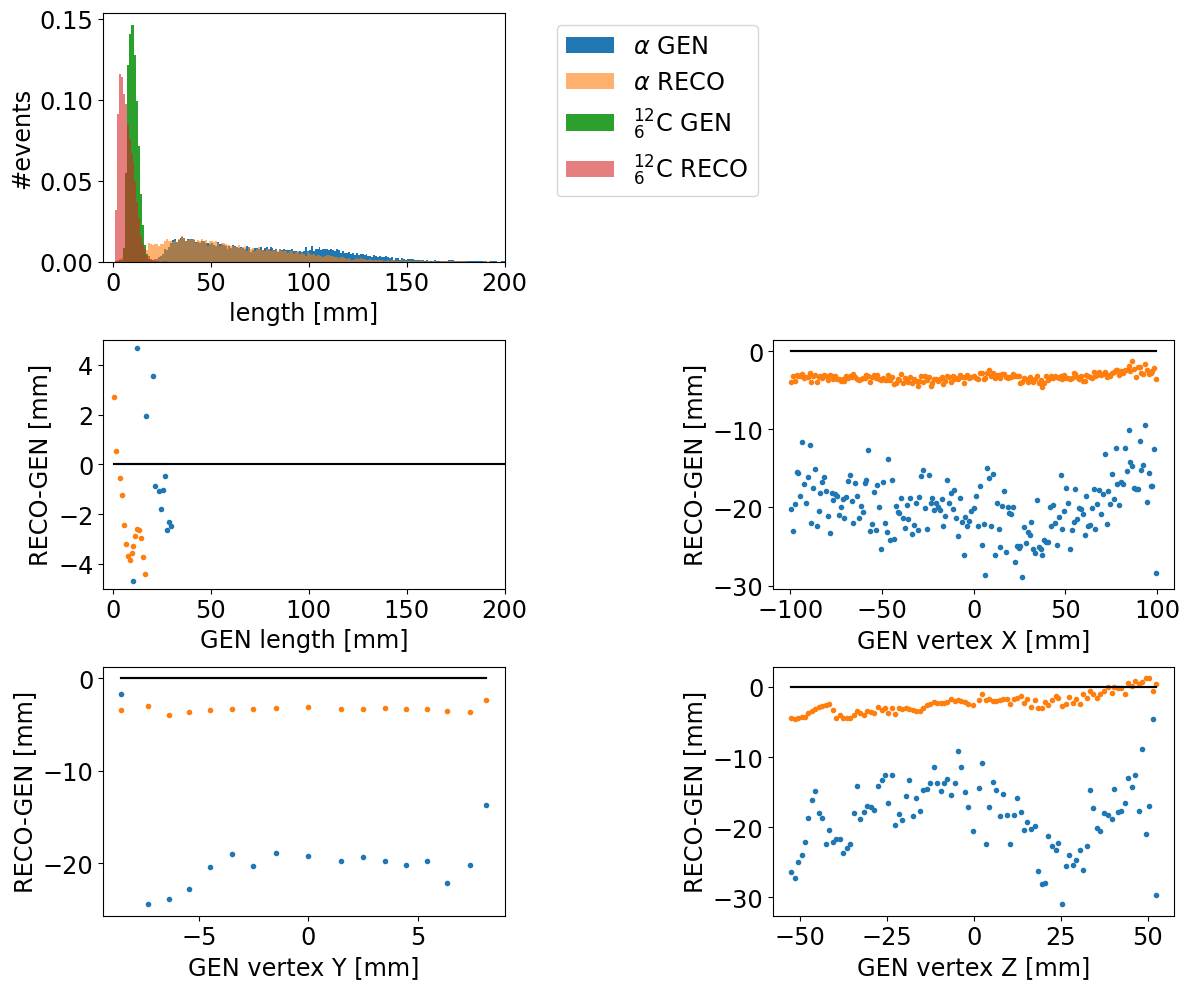

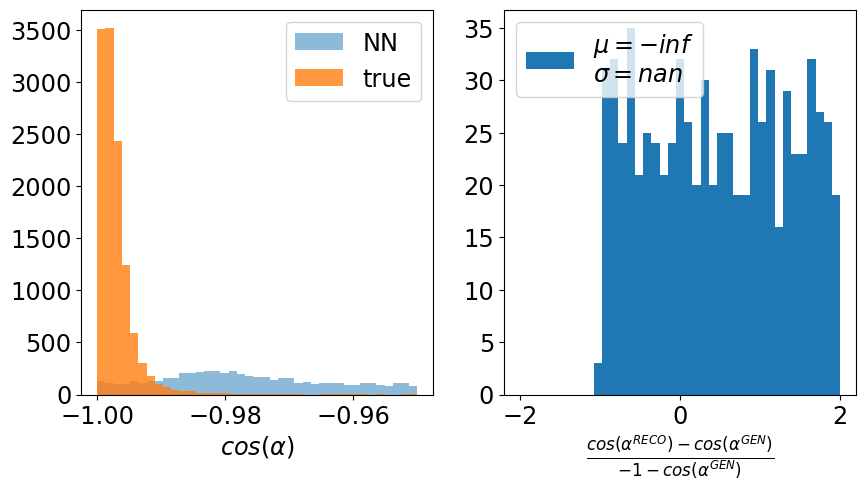

In [72]:
import plotting_functions as plf
importlib.reload(plf)

#plf.controlPlots(df)
plf.plotEndPointRes(df=df, edge="Vtx")
plf.plotEndPointRes(df=df, edge="Alpha")
plf.plotEndPointRes(df=df, edge="Carbon")

plf.plotLengthPull(df, partName="Alpha")
plf.plotLengthPull(df, partName="Carbon")
plf.plotLengthPullEvolution(df)
plf.plotOpeningAngleCos(df)